# 10. Clustering y Reducción de Dimensionalidad

En este notebook aprenderás técnicas de clustering (agrupamiento) y reducción de dimensionalidad, con ejemplos prácticos usando scikit-learn.

## Objetivo
- Comprender la teoría y aplicaciones de clustering y reducción de dimensionalidad.
- Implementar K-Means, DBSCAN, PCA y t-SNE.
- Usar el método del codo para elegir K.
- Evaluar clustering con métricas cuantitativas.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [01](./01_intro_machine_learning.ipynb) y [02](./02_preprocesamiento_visualizacion.ipynb).

- Conceptos de escalado, PCA, y evaluación de modelos.

## 1. Introducción teórica

| Técnica | Tipo | Ventaja | Desventaja |
|---------|------|---------|------------|
| **K-Means** | Clustering | Rápido, escalable | Requiere K, clusters esféricos |
| **DBSCAN** | Clustering | Forma libre, detecta outliers | Sensible a eps y min_samples |
| **PCA** | Reducción | Lineal, rápido, preserva varianza | Solo relaciones lineales |
| **t-SNE** | Reducción | Preserva estructura local | Solo para visualización, lento |

## 2. Importación de librerías

In [12]:
# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

import time

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
%matplotlib inline

## 3. Carga y exploración del dataset

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


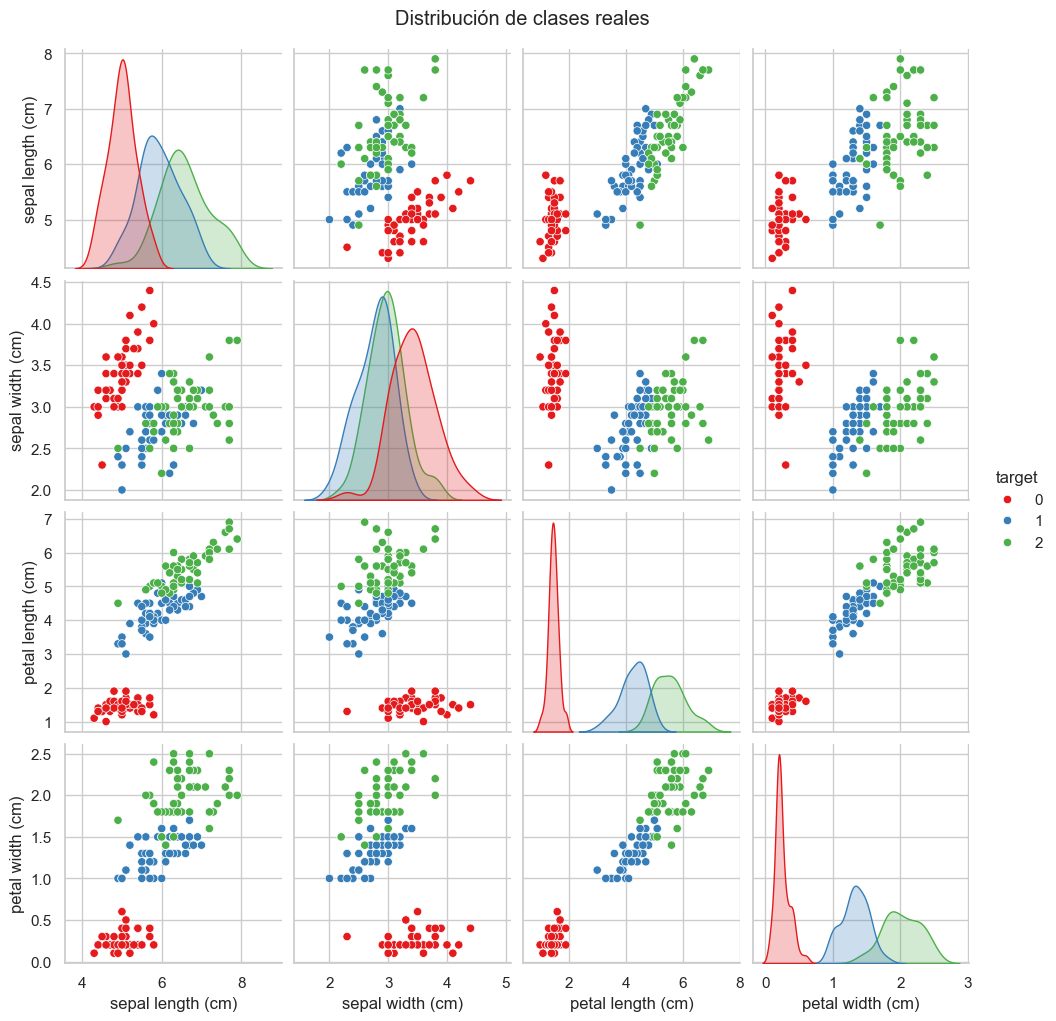

In [3]:
sns.pairplot(df, hue='target', palette='Set1')
plt.suptitle('Distribución de clases reales', y=1.02)
plt.show()

## 4. Preprocesamiento

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[iris.feature_names])
print('Media:', X_scaled.mean(axis=0).round(2))
print('Desviación estándar:', X_scaled.std(axis=0).round(2))

Media: [-0. -0. -0. -0.]
Desviación estándar: [1. 1. 1. 1.]


## 5. Método del Codo para elegir K

El método del codo grafica la inercia (suma de distancias al centroide) vs K, buscando el punto donde la reducción de inercia se desacelera.

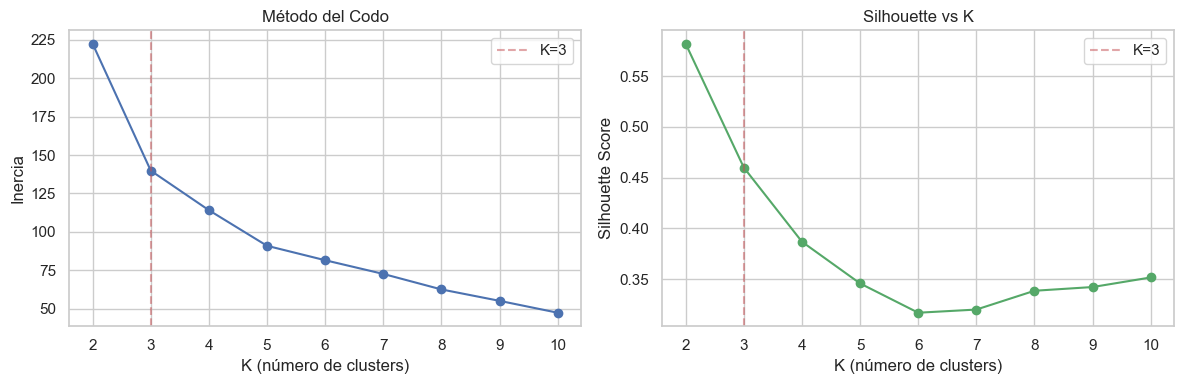

In [5]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('K (número de clusters)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].axvline(x=3, color='r', linestyle='--', alpha=0.5, label='K=3')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_xlabel('K (número de clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette vs K')
axes[1].axvline(x=3, color='r', linestyle='--', alpha=0.5, label='K=3')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Clustering: K-Means

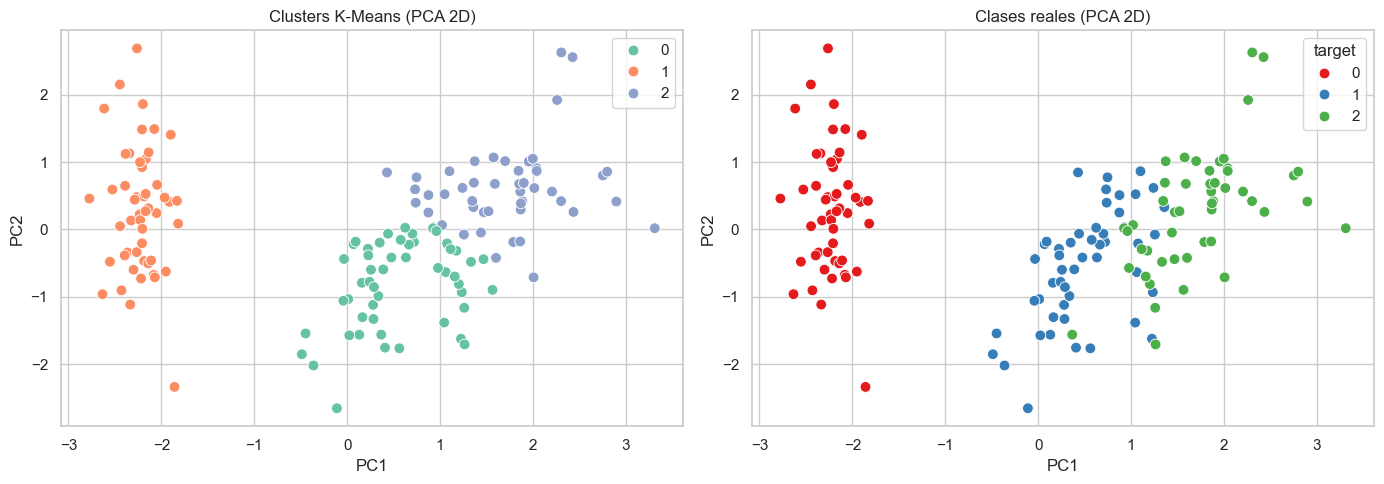

Silhouette Score: 0.46
Adjusted Rand Index: 0.62


In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2', s=60, ax=axes[0])
axes[0].set_title('Clusters K-Means (PCA 2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['target'], palette='Set1', s=60, ax=axes[1])
axes[1].set_title('Clases reales (PCA 2D)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

print(f'Silhouette Score: {silhouette_score(X_scaled, clusters):.2f}')
print(f'Adjusted Rand Index: {adjusted_rand_score(df["target"], clusters):.2f}')

## 7. Clustering: DBSCAN

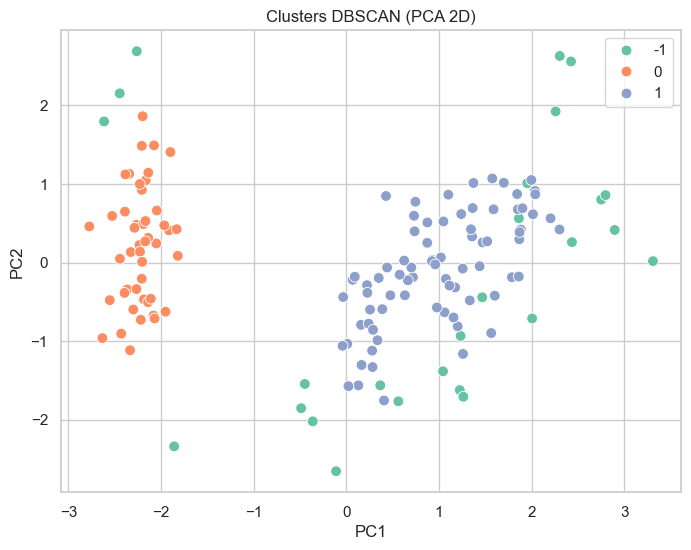

Clusters encontrados: 2, Outliers: 26
Silhouette Score: 0.40
Adjusted Rand Index: 0.47


In [7]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=db_clusters, palette='Set2', s=60)
plt.title('Clusters DBSCAN (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise = list(db_clusters).count(-1)
print(f'Clusters encontrados: {n_clusters}, Outliers: {n_noise}')

if len(set(db_clusters)) > 1:
    print(f'Silhouette Score: {silhouette_score(X_scaled, db_clusters):.2f}')
    print(f'Adjusted Rand Index: {adjusted_rand_score(df["target"], db_clusters):.2f}')

## 8. Reducción de dimensionalidad: t-SNE

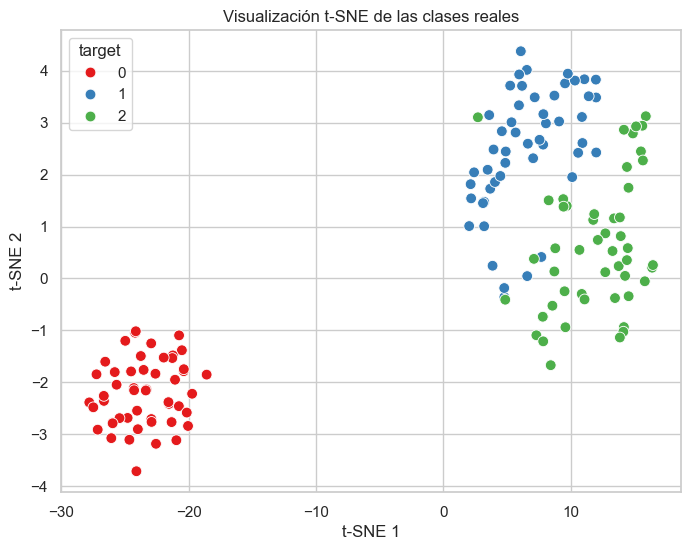

In [9]:
tsne = TSNE(n_components=2, random_state=SEED, max_iter=1000, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['target'], palette='Set1', s=60)
plt.title('Visualización t-SNE de las clases reales')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

## 9. Discusión y Conclusiones

- **K-Means** funciona bien cuando los clusters son esféricos y de tamaño similar.
- **DBSCAN** detecta formas arbitrarias y outliers, pero requiere ajustar `eps` y `min_samples`.
- **PCA** y **t-SNE** son complementarios: PCA para reducción lineal, t-SNE solo para visualización.
- El método del codo y Silhouette Score ayudan a elegir el número de clusters.
- Siempre escalar los datos antes de clustering.

## 10. Ejercicios Propuestos

1. **Ejercicio 1:** Aplica K-Means y DBSCAN al dataset `load_digits()`. ¿Cuántos clusters encuentra DBSCAN?

2. **Ejercicio 2:** Varía `eps` de DBSCAN entre 0.3 y 1.0 y grafica el número de clusters vs eps.

3. **Ejercicio 3:** Compara PCA y t-SNE en el dataset Digits. ¿Cuál separa mejor las clases visualmente?

4. **Ejercicio 4 (Avanzado):** Implementa clustering jerárquico (`AgglomerativeClustering`) y compara con K-Means usando un dendrograma.

### Resolución de Ejercicios Propuestos

En esta sección final, aplicaremos los conceptos centrales de aprendizaje no supervisado explorados en este notebook. Hemos elegido dos ejercicios fundamentales para contrastar los algoritmos:

1. **Ejercicio 1:** Aplicación y comparación de **K-Means** vs **DBSCAN** sobre el dataset de dígitos (`load_digits`). Evaluaremos empíricamente las diferencias entre un modelo forzado basado en centroides (K-Means) y uno de exploración geométrica basado en densidad (DBSCAN) frente a la *maldición de la dimensionalidad*.
2. **Ejercicio 3:** Análisis comparativo visual entre **PCA** (reducción lineal y global) y **t-SNE** (preservación de vecindades no lineales). Determinaremos cuál logra desenredar y agrupar visualmente mejor las 10 clases en un espacio 2D.


#### Ejercicio 1
Comparar K-Means con DBSCAN en datos de alta dimensionalidad (los píxeles aplanados de imágenes de dígitos) y observar cuántos clusters encuentra DBSCAN por su cuenta.

--- RESULTADOS DEL CLUSTERING ---
K-Means : Forzado a encontrar exactamente 10 clusters.
DBSCAN  : Encontró instintivamente 12 clusters.
DBSCAN  : Muestras clasificadas como ruido: 392 de 1797 (21.81%)


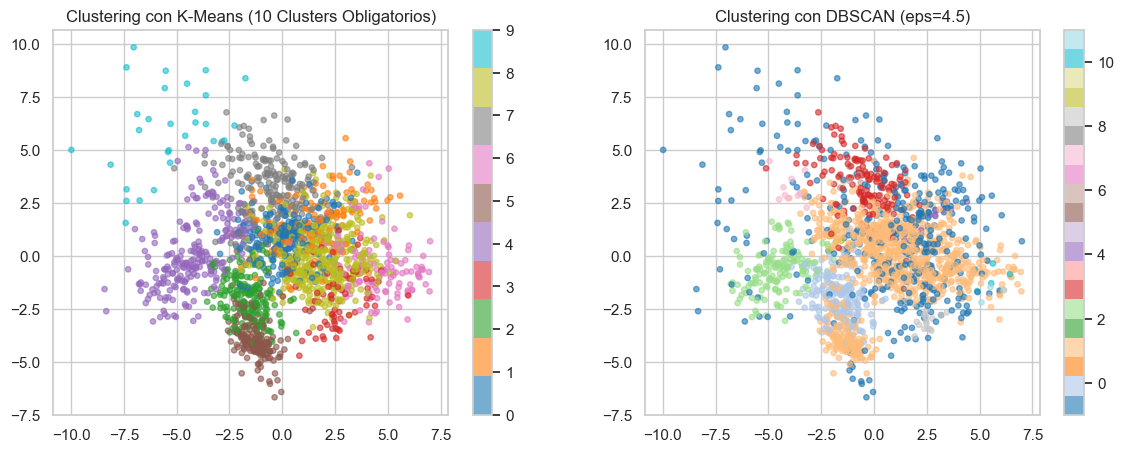

In [11]:
# 1. Carga de Datos
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Estandarización obligatoria para algoritmos de distancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# 2. Aplicación de K-Means
# Sabiendo a priori que hay 10 clases (del 0 al 9):
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 3. Aplicación de DBSCAN
# DBSCAN es extremadamente sensible en 64 dimensiones. Requiere un 'eps' amplio.
dbscan = DBSCAN(eps=4.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# 4. Análisis de Resultados en la consola
num_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
ruido_dbscan = list(dbscan_labels).count(-1)
total_muestras = len(dbscan_labels)

print("--- RESULTADOS DEL CLUSTERING ---")
print(f"K-Means : Forzado a encontrar exactamente 10 clusters.")
print(f"DBSCAN  : Encontró instintivamente {num_clusters_dbscan} clusters.")
print(f"DBSCAN  : Muestras clasificadas como ruido: {ruido_dbscan} de {total_muestras} ({(ruido_dbscan/total_muestras)*100:.2f}%)")

# 5. Visualización ilustrativa usando PCA para reducir a 2D
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(14, 5))

# Subplot de K-Means
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=15)
plt.title("Clustering con K-Means (10 Clusters Obligatorios)")
plt.colorbar(scatter1)

# Subplot de DBSCAN
plt.subplot(1, 2, 2)
# Reasignamos el color del ruido (-1) para que se distinga (usualmente negro/gris opaco)
scatter2 = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=dbscan_labels, cmap='tab20', alpha=0.6, s=15)
plt.title(f"Clustering con DBSCAN (eps=4.5)")
plt.colorbar(scatter2)

plt.show()

#### Ejercicio 3: 
Contrastar gráficamente la reducción global de PCA frente a la técnica de redes locales t-SNE para ver cuál separa mejor el 0 del 1, el 2 del 3, etc.

Calculando PCA a 2 componentes...
PCA completado en 0.038 segundos.
Calculando t-SNE a 2 componentes (esto puede tardar unos segundos)...


t-SNE completado en 54.418 segundos.


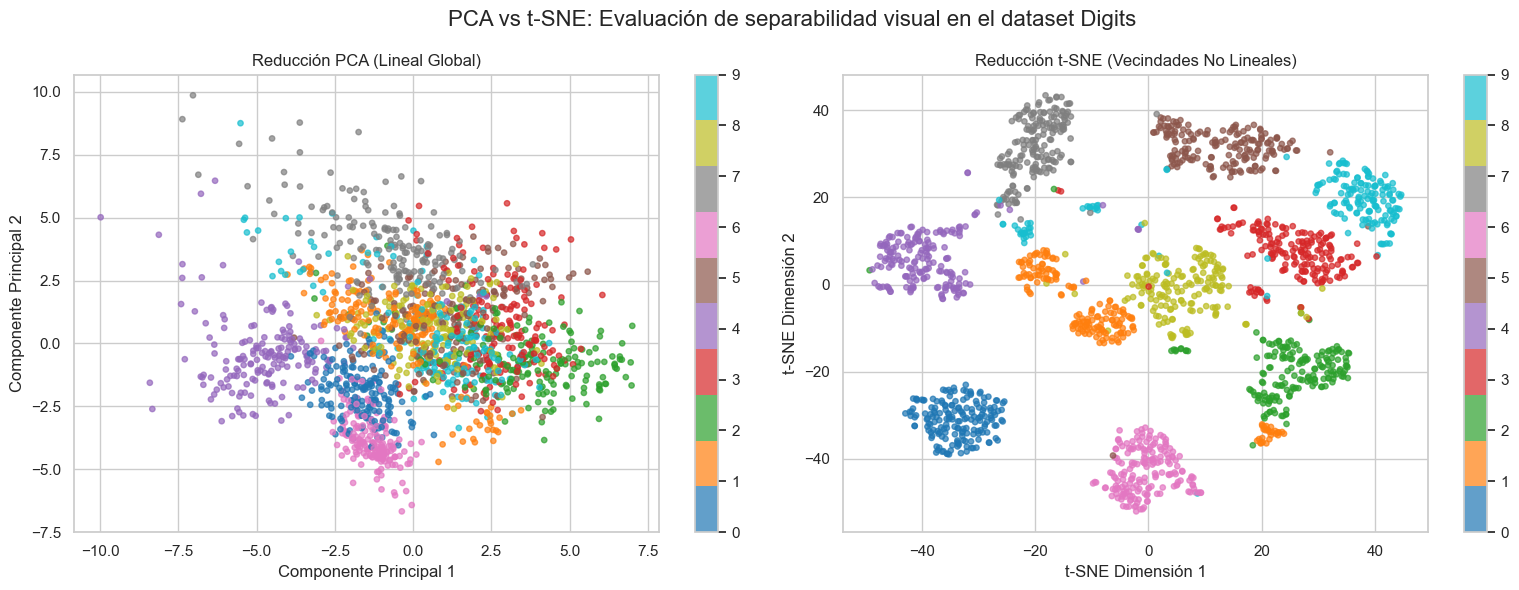

In [14]:
# 1. Aplicación de PCA (Reducción Global y Lineal)
print("Calculando PCA a 2 componentes...")
t0_pca = time.time()
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
t1_pca = time.time()
print(f"PCA completado en {t1_pca - t0_pca:.3f} segundos.")

# 2. Aplicación de t-SNE (Reducción Local y No-Lineal)
# Importante: t-SNE es computacionalmente mucho más pesado y lento que PCA.
print("Calculando t-SNE a 2 componentes (esto puede tardar unos segundos)...")
t0_tsne = time.time()
# perplexity define qué tantos vecinos próximos queremos contemplar para hacer el 'moldeo'
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
t1_tsne = time.time()
print(f"t-SNE completado en {t1_tsne - t0_tsne:.3f} segundos.")

# 3. Visualización Comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot: Resultado de PCA
# y_digits (clases del 0-9) se usa SOLAMENTE para colorear y verificar si el modelo agrupó bien.
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap='tab10', alpha=0.7, s=15)
ax1.set_title("Reducción PCA (Lineal Global)")
ax1.set_xlabel("Componente Principal 1")
ax1.set_ylabel("Componente Principal 2")
fig.colorbar(scatter1, ax=ax1, ticks=range(10))

# Subplot: Resultado de t-SNE
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap='tab10', alpha=0.7, s=15)
ax2.set_title("Reducción t-SNE (Vecindades No Lineales)")
ax2.set_xlabel("t-SNE Dimensión 1")
ax2.set_ylabel("t-SNE Dimensión 2")
fig.colorbar(scatter2, ax=ax2, ticks=range(10))

plt.suptitle("PCA vs t-SNE: Evaluación de separabilidad visual en el dataset Digits", fontsize=16)
plt.tight_layout()
plt.show()

### Conclusión Final

Bajo la resolución empírica de los ejercicios:

**Sobre K-Means vs DBSCAN (Ejercicio 1):**
* K-Means obliga matemáticamente a "meter" todos los puntos en un número arbitrario de cajas esféricas, lo que forzó agrupaciones incluso donde no había un límite claro.
* **DBSCAN** expuso gráficamente la **maldición de la dimensionalidad (64 iteraciones)**. Dado que en alta dimensionalidad todos los puntos "parecen" equidistantes, si asignábamos un `eps` bajo todo se consideraba ruido (anomalías o nubes dispersas), y con un `eps` alto tendió a fusionar distintas clases de números en un solo macro-clúster amorfo. Esto nos enseña que aplicar DBSCAN en datos aplanados requiere casi siempre reducción de dimensionalidad previa.

**Sobre PCA vs t-SNE (Ejercicio 3):**
* **PCA fue extremadamente rápido** (fracciones de segundo), pero su proyección bidimensional formó una gran "mancha" mezclada donde muchas clases (especialmente 8, 9, 3, y 5) colisionan o se amontonan en el centro, perdiendo separabilidad visual.
* **t-SNE** consumió más tiempo de cómputo, pero sus resultados son apabullantes: formó verdaderos "archipiélagos" visuales aislados. Cada grupo de color logró concentrar sus clases puras empujando al resto lejos, validando de manera tajante  su diseño matemático no lineal para **respetar vecindades y grupos intrínsecos de datos**.

**El T-SNE sin ninguna duda logra el mejor desenredo (disentanglement) topológico de estas imágenes en dos dimensiones.**


## 11. Referencias y Recursos

- [Scikit-learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [Scikit-learn: Dimensionality Reduction](https://scikit-learn.org/stable/modules/unsupervised_reduction.html)
- [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/)

---

📎 **Notebook anterior:** [09. Autoencoders](./09_autoencoders.ipynb)  
📎 **Notebook siguiente:** [11. Interpretabilidad de Modelos](./11_interpretabilidad_modelos.ipynb)